
Tren Meckel <br>
Dr. Truex<br>
CS 323: Data Privacy<br>
8 October 2025<br>


# Project 3: Secret Sharing 
###### shhhhhhhhhhhhhhh secret

##### SMPC Average Computation Project
###### This notebook computes the average of randomly generated integers using three approaches:
###### 1. Non-private computation (no privacy protection)
###### 2. Paillier homomorphic encryption (additively homomorphic SMPC)
###### 3. Shamir's secret sharing (threshold-based SMPC)
##### The runtime for each method is measured for different numbers of input values, and the
##### comparison results are visualized in a runtime graph.

## Import Statements

In [1]:
import numpy as np                # numpy` for random integer generation
import time                       # `time` for runtime measurement
import matplotlib.pyplot as plt   # for plotting
from phe import paillier          # `phe` for Paillier encryption
import random                     # for generating Shamir polynomial coefficients

#### Step 1: Generate Random Values
#### -------------------------------------------------------------------
###### Generates `n` random integers in the range [low, high].
###### These integers represent the "private values" each party might hold.
###### The same generated set is used for all three computation methods
###### to ensure fair and consistent timing comparisons.


In [3]:
def generate_values(n, low=1, high=100):
    return np.random.randint(low, high + 1, size=n)

#### Step 2: Non-private Average Computation
#### -------------------------------------------------------------------
###### Computes the average directly using numpy, without any privacy protection.
###### This represents the baseline case with no encryption or secret sharing overhead.

In [6]:
def compute_average_non_private(values):
    start = time.time()         # record start time          
    average = np.mean(values)   # directly compute average
    end = time.time()           # record end time
    return average, end - start # return result and elapsed time

#### Step 3: Paillier Homomorphic Encryption
#### -------------------------------------------------------------------
##### Uses the Paillier cryptosystem to perform privacy-preserving averaging.
#### Steps:
######   1. Generate a public/private keypair.
######   2. Encrypt each value using the public key.
######   3. Sum all encrypted values (supported homomorphically).
######   4. Decrypt the sum using the private key.
######   5. Divide by number of values to obtain the average.
#####
##### Timing starts after key generation to isolate the runtime
##### of encryption and homomorphic operations only.

In [8]:
def compute_average_paillier(values):
    public_key, private_key = paillier.generate_paillier_keypair()

    start = time.time()
    encrypted_values = [public_key.encrypt(int(v)) for v in values] # encrypt the values
    encrypted_sum = sum(encrypted_values)                           # homomorphic addition
    average = private_key.decrypt(encrypted_sum) / len(values)      # decrypt and compute average
    end = time.time()
    
    return average, end - start

#### Step 4: Shamir's Secret Sharing
#### -------------------------------------------------------------------
###### Implements Shamir's (t, n) secret sharing scheme from scratch.
###### Each value is split into n shares using a randomly generated polynomial
###### of degree (threshold - 1), where any `threshold` number of shares
###### can reconstruct the secret via Lagrange interpolation.
#####
##### All operations are performed modulo a large prime to maintain
##### finite-field arithmetic and prevent overflow.

In [10]:
# Large prime modulus for finite-field arithmetic
PRIME = 2**2048 - 189

def shamir_split(secret, total_parties, threshold, prime=PRIME):
    """
    Split a secret into 'total_parties' shares using Shamir's Secret Sharing.
    Any 'threshold' shares can reconstruct the original secret.
    """
    coeffs = [secret] + [random.randint(0, prime - 1) for _ in range(threshold - 1)]
    shares = []
    for x in range(1, total_parties + 1):
        y = sum([coeffs[i] * pow(x, i, prime) for i in range(threshold)]) % prime
        shares.append((x, y))
    return shares


def shamir_reconstruct(shares, threshold, prime=PRIME):
    """
    Reconstruct a secret from a given set of shares using Lagrange interpolation.
    """
    selected_shares = shares[:threshold]
    x_s, y_s = zip(*selected_shares)
    secret = 0
    for j in range(threshold):
        numerator = 1
        denominator = 1
        for m in range(threshold):
            if m != j:
                numerator = (numerator * (-x_s[m])) % prime
                denominator = (denominator * (x_s[j] - x_s[m])) % prime
        lagrange_coeff = numerator * pow(denominator, -1, prime)
        secret = (secret + y_s[j] * lagrange_coeff) % prime
    return secret


def compute_average_shamir(total_parties, threshold, prime=PRIME, low=1, high=100):
    """
    Simulate a Shamir's Secret Sharing average computation where:
      - Each of 'total_parties' holds one private integer value.
      - Each value is shared among all parties.
      - The parties collaboratively reconstruct the average using a threshold number of shares.
    """
    # Step 1: Generate one secret value per party
    values = np.random.randint(low, high + 1, size=total_parties)

    start = time.time()

    # Step 2: Split each party's secret into shares
    all_shares = [shamir_split(int(v), total_parties, threshold, prime) for v in values]

    # Step 3: Each party sums its received shares
    party_sums = []
    for i in range(total_parties):
        # sum all y-values this party receives across all secrets
        party_sum = sum([shares[i][1] for shares in all_shares]) % prime
        party_sums.append((i + 1, party_sum))

    # Step 4: Reconstruct the total sum using a subset of shares (threshold)
    total_sum = shamir_reconstruct(party_sums[:threshold], threshold, prime)

    # Step 5: Compute the average
    average = total_sum / total_parties

    end = time.time()
    return average, end - start

#### Step 5: Run Experiments
#### -------------------------------------------------------------------
###### Runs all three average computation methods for multiple dataset sizes (n_values).
###### For each n:
######   - Random integers are generated.
######   - Each method is executed once.
######   - Runtimes are recorded and printed for progress tracking.
#### This loop provides the empirical data for runtime comparison.

In [16]:
# Experiment settings
n_values = [10, 50, 100, 250, 500]

# Lists to store runtimes
runtimes_non_private = []
runtimes_paillier = []
runtimes_shamir = []

for n in n_values:
    print(f"Running experiment for n = {n} parties...")
    threshold = n // 2  # threshold = half the parties
    values = np.random.randint(1, 101, size=n)

    # Non-private
    _, rt_non = compute_average_non_private(values)

    # Paillier
    _, rt_pail = compute_average_paillier(values)

    # Shamir (party-based)
    _, rt_sham = compute_average_shamir(n, threshold)

    runtimes_non_private.append(rt_non)
    runtimes_paillier.append(rt_pail)
    runtimes_shamir.append(rt_sham)

    print(f"  Completed n = {n} | Non-private: {rt_non:.4f}s | Paillier: {rt_pail:.4f}s | Shamir: {rt_sham:.4f}s\n")

print("All experiments completed successfully!")

Running experiment for n = 10 parties...
  Completed n = 10 | Non-private: 0.0001s | Paillier: 3.0546s | Shamir: 0.0004s

Running experiment for n = 50 parties...
  Completed n = 50 | Non-private: 0.0000s | Paillier: 13.5917s | Shamir: 0.0367s

Running experiment for n = 100 parties...
  Completed n = 100 | Non-private: 0.0000s | Paillier: 26.8457s | Shamir: 0.4317s

Running experiment for n = 250 parties...
  Completed n = 250 | Non-private: 0.0001s | Paillier: 65.4630s | Shamir: 13.2428s

Running experiment for n = 500 parties...
  Completed n = 500 | Non-private: 0.0000s | Paillier: 130.0811s | Shamir: 212.8965s

All experiments completed successfully!


#### Step 6: Plots Runtime Comparison
#### -------------------------------------------------------------------
##### Generates a plot comparing runtime growth for each method as n increases.
##### Uses a logarithmic y-axis to make differences between scales more visible.
##### The plot is saved both as a PNG and PDF for easy inclusion in thee write-up.
###### all the graphs...

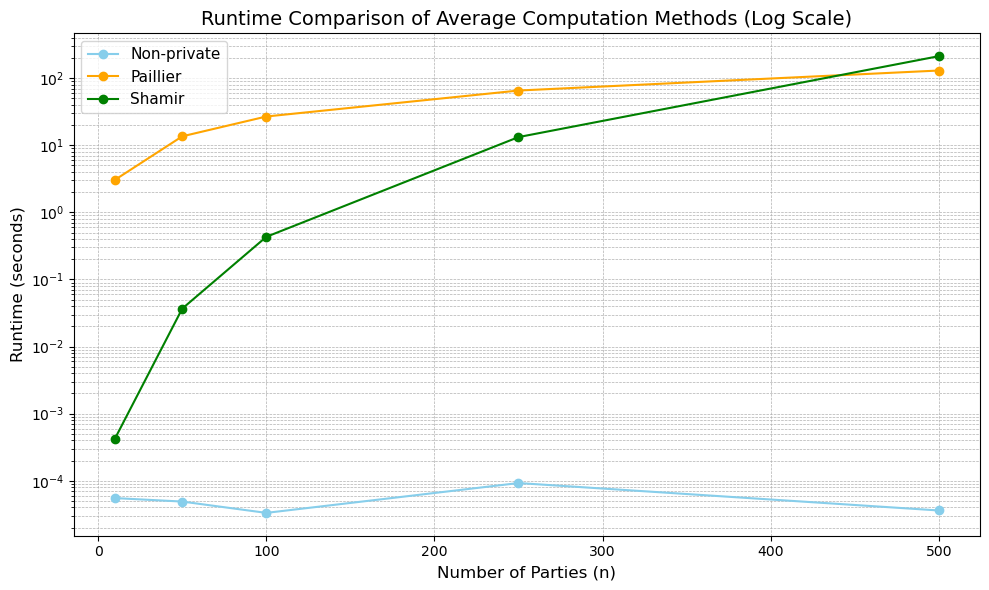

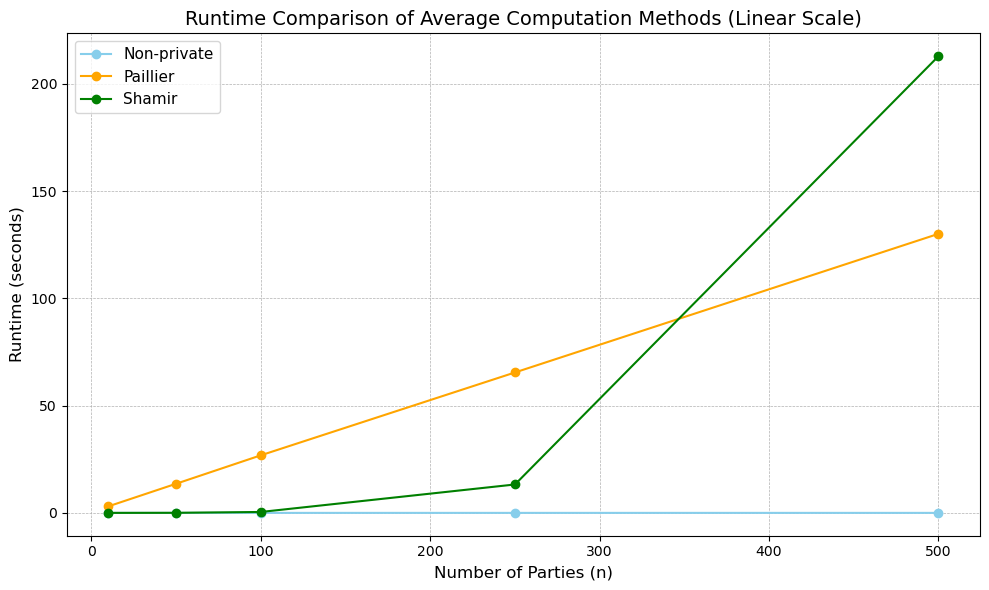

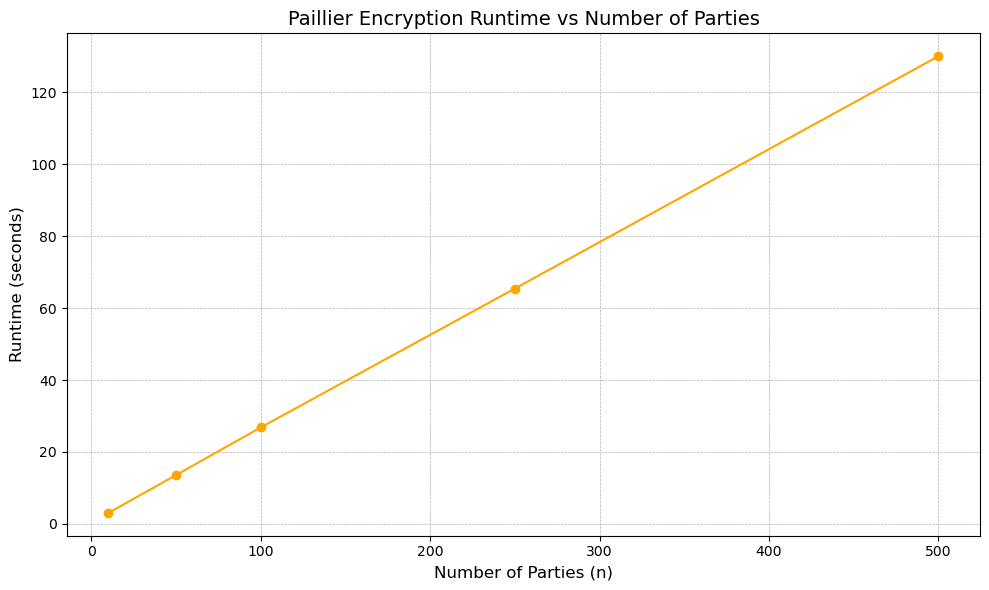

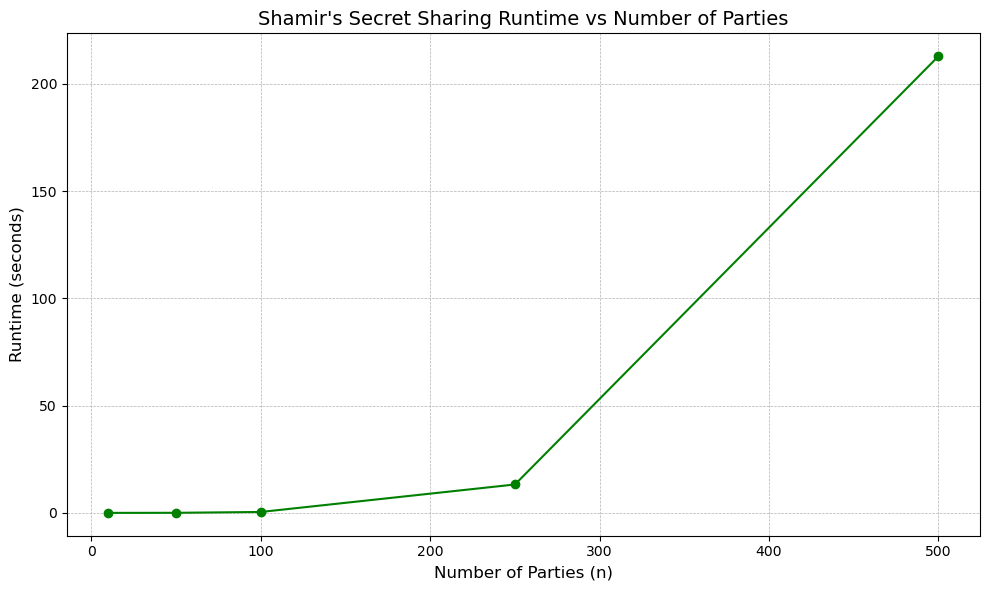

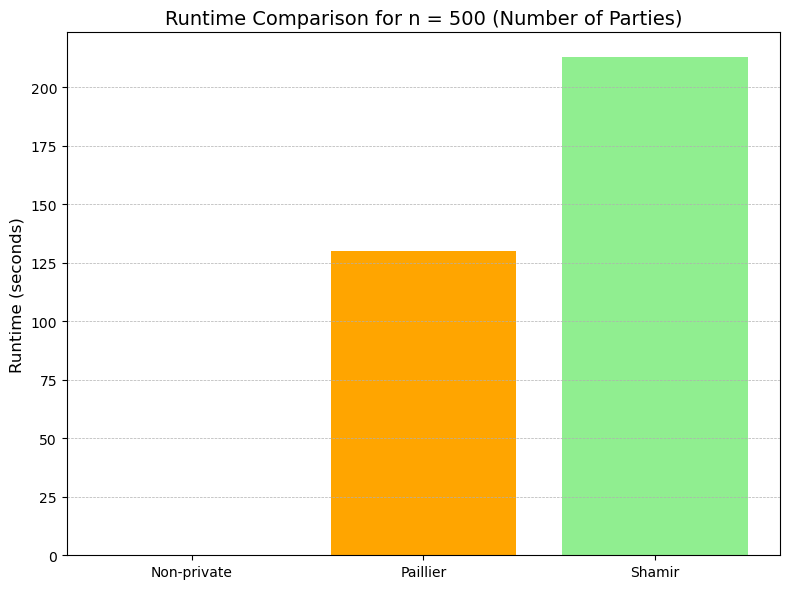

In [22]:
# === 1. Log-scale runtime comparison ===
plt.figure(figsize=(10,6))
plt.plot(n_values, runtimes_non_private, marker='o', color='skyblue', label="Non-private")
plt.plot(n_values, runtimes_paillier, marker='o', color='orange', label="Paillier")
plt.plot(n_values, runtimes_shamir, marker='o', color='green', label="Shamir")

plt.xlabel("Number of Parties (n)", fontsize=12)
plt.ylabel("Runtime (seconds)", fontsize=12)
plt.title("Runtime Comparison of Average Computation Methods (Log Scale)", fontsize=14)
plt.yscale("log")
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()

plt.savefig("runtime_comparison_plot.png", dpi=300, bbox_inches='tight')
plt.savefig("runtime_comparison_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()


# === 2. Linear-scale runtime comparison ===
plt.figure(figsize=(10,6))
plt.plot(n_values, runtimes_non_private, marker='o', color='skyblue', label="Non-private")
plt.plot(n_values, runtimes_paillier, marker='o', color='orange', label="Paillier")
plt.plot(n_values, runtimes_shamir, marker='o', color='green', label="Shamir")

plt.xlabel("Number of Parties (n)", fontsize=12)
plt.ylabel("Runtime (seconds)", fontsize=12)
plt.title("Runtime Comparison of Average Computation Methods (Linear Scale)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()

plt.savefig("runtime_comparison_linear.png", dpi=300, bbox_inches='tight')
plt.savefig("runtime_comparison_linear.pdf", dpi=300, bbox_inches='tight')
plt.show()


# === 3. Paillier-only runtime plot ===
plt.figure(figsize=(10,6))
plt.plot(n_values, runtimes_paillier, marker='o', color='orange')
plt.xlabel("Number of Parties (n)", fontsize=12)
plt.ylabel("Runtime (seconds)", fontsize=12)
plt.title("Paillier Encryption Runtime vs Number of Parties", fontsize=14)
plt.grid(True, ls="--", lw=0.5)
plt.tight_layout()

plt.savefig("paillier_runtime.png", dpi=300, bbox_inches='tight')
plt.savefig("paillier_runtime.pdf", dpi=300, bbox_inches='tight')
plt.show()


# === 4. Shamir-only runtime plot ===
plt.figure(figsize=(10,6))
plt.plot(n_values, runtimes_shamir, marker='o', color='green')
plt.xlabel("Number of Parties (n)", fontsize=12)
plt.ylabel("Runtime (seconds)", fontsize=12)
plt.title("Shamir's Secret Sharing Runtime vs Number of Parties", fontsize=14)
plt.grid(True, ls="--", lw=0.5)
plt.tight_layout()

plt.savefig("shamir_runtime.png", dpi=300, bbox_inches='tight')
plt.savefig("shamir_runtime.pdf", dpi=300, bbox_inches='tight')
plt.show()


# === 5. Bar chart for fixed n (using n = 500) ===
fixed_index = n_values.index(500)
methods = ["Non-private", "Paillier", "Shamir"]
runtimes_fixed = [
    runtimes_non_private[fixed_index],
    runtimes_paillier[fixed_index],
    runtimes_shamir[fixed_index]
]

plt.figure(figsize=(8,6))
plt.bar(methods, runtimes_fixed, color=["skyblue", "orange", "lightgreen"])
plt.ylabel("Runtime (seconds)", fontsize=12)
plt.title("Runtime Comparison for n = 500 (Number of Parties)", fontsize=14)
plt.grid(axis="y", ls="--", lw=0.5)
plt.tight_layout()

plt.savefig("runtime_bar_fixed_n.png", dpi=300, bbox_inches='tight')
plt.savefig("runtime_bar_fixed_n.pdf", dpi=300, bbox_inches='tight')
plt.show()
